In [4]:
from pathlib import Path
import os
import sys

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Python: {sys.executable}')
print(f'Project root: {project_root}')
print(f'Data folder exists: {(project_root / "data").exists()}')

Python: /Users/teresa/Desktop/Computational_Intelligence_Teresa_Vaccari/.venv/bin/python
Project root: /Users/teresa/Desktop/Computational_Intelligence_Teresa_Vaccari
Data folder exists: True


# Neural Network for WMH Segmentation

Essential workflow: build a pixel-wise DataFrame, handle class imbalance, train a neural network, plot learning curves, and evaluate with confusion matrices.

In [5]:
from pathlib import Path
import os
import sys

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
print(f"Project root: {project_root}")
os.environ["MPLCONFIGDIR"] = str(project_root / ".matplotlib-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

from wmh_preprocessing import load_dataset, prepare_slice_features

data_dir = project_root / "data"
output_dir = project_root / "nn_output"
output_dir.mkdir(exist_ok=True)


feature_columns = [
    "intensity",
    "local_mean",
    "local_std",
    "skewness",
    "kurtosis",
    "local_contrast",
    "local_range",
    "x",
    "y",
]

Project root: /Users/teresa/Desktop/Computational_Intelligence_Teresa_Vaccari


## Build The DataFrame

Each row is one pixel. `wmh` is the binary target label.

In [6]:
def select_slices(mask_volume):
    lesion_pixels = mask_volume.sum(axis=(0, 1))
    return np.flatnonzero(lesion_pixels) # select slices with at least one wmh pixel


def build_dataframe(data, slice_indices):
    frames = []

    # per ogni slice scelta, calcola le feature normalizzate e prendi la corrispondente maschera WMH da usare come label.
    for slice_idx in slice_indices:
        features = prepare_slice_features(data, slice_idx)
        mask = data["mask"][:, :, slice_idx].astype(np.uint8)

        frames.append(
            pd.DataFrame(
                {
                    "slice_idx": slice_idx,
                    "intensity": features["intensity"].ravel(),
                    "local_mean": features["mean"].ravel(),
                    "local_std": features["std"].ravel(),
                    "skewness": features["skew"].ravel(),
                    "kurtosis": features["kurtosis"].ravel(),
                    "local_contrast": features["contrast"].ravel(),
                    "local_range": features["range"].ravel(),
                    "x": features["x"].ravel(),
                    "y": features["y"].ravel(),
                    "wmh": mask.ravel(),
                }
            )
        )

    return pd.concat(frames, ignore_index=True)


#def summary(name, df):
#    positives = int(df["wmh"].sum())
#    print(f"{name}: {len(df):,} pixels | WMH {positives:,} ({100 * positives / len(df):.3f}%)")


data = load_dataset(data_dir)
slice_indices = select_slices(data["mask"])
df = build_dataframe(data, slice_indices)

#summary("Full dataset", df)
print(f"Number of selected slices: {len(slice_indices)}")

print("Feature summary:")
display(df[feature_columns + ["wmh"]].agg(["min", "max", "mean"]))

print("Random pixels with at least one non-zero feature:")
non_background = df[df[feature_columns].sum(axis=1) > 0]
display(non_background.sample(10, random_state=42))

print("Random WMH pixels:")
display(df[df["wmh"] == 1].sample(10, random_state=42))


Number of selected slices: 611
Feature summary:


,intensity,local_mean,local_std,skewness,kurtosis,local_contrast,local_range,x,y,wmh
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.994624,0.993377,1.000000
mean,0.352285,0.397473,0.148265,0.454811,0.240964,0.464529,0.215587,0.497312,0.496689,0.008691


Random pixels with at least one non-zero feature:


,slice_idx,intensity,local_mean,local_std,skewness,kurtosis,local_contrast,local_range,x,y,wmh
12651807,450,0.115528,0.115946,0.282411,0.676937,0.276547,0.537218,0.443149,0.467742,0.463576,0
3193560,113,0.655473,0.743132,0.075802,0.530241,0.266071,0.525006,0.099906,0.677419,0.701987,0
1182907,42,0.617128,0.590203,0.442524,0.489150,0.266902,0.709868,0.469731,0.715054,0.112583,0
11934803,424,0.249057,0.437183,0.522443,0.625487,0.247890,0.319203,0.772019,0.607527,0.933775,0
7458690,265,0.289371,0.250299,0.435182,0.679719,0.296819,0.543044,0.534409,0.483871,0.562914,0
10176885,362,0.448586,0.517849,0.165171,0.609449,0.311731,0.373408,0.512808,0.435484,0.344371,0
2147837,76,0.100518,0.087410,0.057874,0.607441,0.271765,0.544100,0.072895,0.510753,0.470199,0
1249742,44,0.000000,0.000000,0.000000,0.000000,0.000000,0.535649,0.248590,0.043011,0.496689,0
14909961,530,0.000000,0.000000,0.000000,0.000000,0.000000,0.438140,0.000000,0.080645,0.867550,0
15450025,550,0.539645,0.471654,0.583379,0.540932,0.216548,0.607305,0.542040,0.650538,0.092715,0


Random WMH pixels:


,slice_idx,intensity,local_mean,local_std,skewness,kurtosis,local_contrast,local_range,x,y,wmh
2910957,103,0.729684,0.760782,0.412438,0.608940,0.216562,0.577157,0.413078,0.306452,0.642384,1
3134971,111,0.681214,0.829108,0.339620,0.607322,0.252001,0.427452,0.447822,0.682796,0.615894,1
8613527,306,0.974191,0.938073,0.162908,0.511011,0.274326,0.598141,0.326271,0.284946,0.682119,1
7350644,261,0.741130,0.737311,0.262076,0.573101,0.221393,0.572579,0.346909,0.591398,0.715232,1
8332863,296,0.785688,0.864378,0.176519,0.392193,0.405643,0.576718,0.225710,0.338710,0.688742,1
13501049,480,0.608642,0.643638,0.070093,0.621124,0.253428,0.462007,0.106442,0.284946,0.701987,1
7341928,261,0.742072,0.748462,0.214102,0.554219,0.214231,0.559283,0.269050,0.731183,0.403974,1
6971154,248,0.641832,0.704463,0.035287,0.604354,0.261673,0.449230,0.148443,0.322581,0.205298,1
15241815,542,0.728631,0.728323,0.166407,0.561562,0.209233,0.558130,0.147469,0.241935,0.682119,1
14511788,516,0.904515,0.930805,0.245740,0.402200,0.456002,0.508615,0.647778,0.365591,0.688742,1


## Split And Balance Training Set

The split is done by slice. Only the training set is downsampled to reduce class imbalance.

In [7]:
slices = df["slice_idx"].unique()
train_slices, val_test_slices = train_test_split(
    slices,
    test_size=0.30,
    random_state=42,
)
val_slices, test_slices = train_test_split(
    val_test_slices,
    test_size=0.50,
    random_state=42,
)

train_df = df[df["slice_idx"].isin(train_slices)].copy()
val_df = df[df["slice_idx"].isin(val_slices)].copy()
test_df = df[df["slice_idx"].isin(test_slices)].copy()

positives = train_df[train_df["wmh"] == 1] 
negatives = train_df[train_df["wmh"] == 0]
sampled_negatives = negatives.sample( # downsample dei pixel negativi per bilanciare il dataset
    n=min(len(negatives), len(positives)*4), # max 2 pixel negativi per ogni pixel positivo
    random_state=42,
)
train_balanced_df = pd.concat([positives, sampled_negatives], ignore_index=True) # dataset bilanciato
train_balanced_df = train_balanced_df.sample(frac=1, random_state=42) # shuffle del dataset bilanciato

## Scale Features And Train Neural Network

In [10]:
from copy import deepcopy
from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPClassifier
import warnings
import numpy as np

def cross_entropy_loss(model, X, y):
    proba = model.predict_proba(X)
    proba = np.clip(proba, 1e-10, 1 - 1e-10)
    loss = -np.mean(y * np.log(proba[:, 1]) + (1 - y) * np.log(proba[:, 0]))
    return loss

def dice_score(y_true, y_pred):
    y_true = np.asarray(y_true).astype(bool)
    y_pred = np.asarray(y_pred).astype(bool)
    denom = y_true.sum() + y_pred.sum()
    return 1.0 if denom == 0 else 2 * np.logical_and(y_true, y_pred).sum() / denom

X_train = train_balanced_df[feature_columns].to_numpy()
y_train = train_balanced_df["wmh"].to_numpy()
X_val = val_df[feature_columns].to_numpy()
y_val_np = val_df["wmh"].to_numpy()

# Campione fisso del validation per ricerca soglia (più veloce)
rng = np.random.default_rng(42)
val_sample_idx = rng.choice(len(y_val_np), size=min(50000, len(y_val_np)), replace=False)
X_val_sample = X_val[val_sample_idx]
y_val_sample = y_val_np[val_sample_idx]

train_losses = []
val_losses = []
val_dice_scores = []

model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=512,
    learning_rate_init=1e-3,
    max_iter=1,
    warm_start=True,
    random_state=42,
    verbose=False,
)

n_epochs = 100
patience = 10
min_delta = 1e-4
no_improve = 0
best_val_loss = np.inf
best_model = None


from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)


for epoch in range(n_epochs):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        model.fit(X_train, y_train, sample_weight=sample_weights)

    tl = cross_entropy_loss(model, X_train, y_train)
    vl = cross_entropy_loss(model, X_val, y_val_np)

    # Ricerca soglia ottimale sul campione validation
    val_probs_sample = model.predict_proba(X_val_sample)[:, 1]
    best_epoch_dice = -np.inf
    best_epoch_threshold = 0.5
    for thr in np.linspace(0.01, 0.99, 99):
        y_pred_thr = (val_probs_sample >= thr).astype(np.uint8)
        d = dice_score(y_val_sample, y_pred_thr)
        if d > best_epoch_dice:
            best_epoch_dice = d
            best_epoch_threshold = thr

    train_losses.append(tl)
    val_losses.append(vl)
    val_dice_scores.append(best_epoch_dice)

    print(f"Epoch {epoch+1:3d} | Train loss: {tl:.4f} | Val loss: {vl:.4f} | Val Dice: {best_epoch_dice:.4f} (thr={best_epoch_threshold:.2f})")

    if vl < best_val_loss - min_delta:
        best_val_loss = vl
        best_model = deepcopy(model)
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

if best_model is not None:
    model = best_model
    print(f"Restored best model with validation loss: {best_val_loss:.4f}")

Epoch   1 | Train loss: 0.2052 | Val loss: 0.2072 | Val Dice: 0.4854 (thr=0.97)
Epoch   2 | Train loss: 0.2026 | Val loss: 0.2082 | Val Dice: 0.5098 (thr=0.98)
Epoch   3 | Train loss: 0.1884 | Val loss: 0.1927 | Val Dice: 0.5275 (thr=0.98)
Epoch   4 | Train loss: 0.1809 | Val loss: 0.1870 | Val Dice: 0.5753 (thr=0.98)
Epoch   5 | Train loss: 0.1590 | Val loss: 0.1639 | Val Dice: 0.6305 (thr=0.99)
Epoch   6 | Train loss: 0.1388 | Val loss: 0.1413 | Val Dice: 0.6812 (thr=0.99)
Epoch   7 | Train loss: 0.1294 | Val loss: 0.1299 | Val Dice: 0.6896 (thr=0.99)
Epoch   8 | Train loss: 0.1249 | Val loss: 0.1251 | Val Dice: 0.7016 (thr=0.99)
Epoch   9 | Train loss: 0.1180 | Val loss: 0.1170 | Val Dice: 0.7103 (thr=0.99)
Epoch  10 | Train loss: 0.1145 | Val loss: 0.1128 | Val Dice: 0.7197 (thr=0.99)
Epoch  11 | Train loss: 0.1116 | Val loss: 0.1095 | Val Dice: 0.7281 (thr=0.99)
Epoch  12 | Train loss: 0.1094 | Val loss: 0.1071 | Val Dice: 0.7214 (thr=0.99)
Epoch  13 | Train loss: 0.1093 | Val los

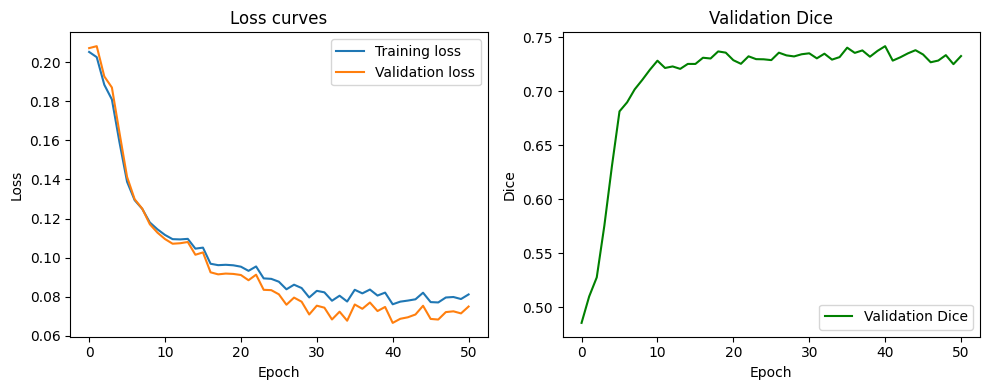

In [12]:
# Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_dice_scores, label="Validation Dice", color="green")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Validation Dice")
plt.legend()

plt.tight_layout()
plt.savefig(output_dir / "learning_curves.png", dpi=150)
plt.show()

In [13]:
# salva il best model
import joblib

joblib.dump(model, output_dir / "best_model.pkl")
# joblib.dump(scaler, output_dir / "scaler.pkl")  # se usi uno scaler

model = joblib.load(output_dir / "best_model.pkl")
# scaler = joblib.load(output_dir / "scaler.pkl")

## Evaluate Model

The probability threshold is selected on the validation set by maximizing Dice score.

In [14]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return 0.0 if tn + fp == 0 else tn / (tn + fp)


def predict(model, df, threshold):
    X = df[feature_columns].to_numpy()
    probabilities = model.predict_proba(X)[:, 1]
    return (probabilities >= threshold).astype(np.uint8)


X_val = val_df[feature_columns].to_numpy()
y_val = val_df["wmh"].to_numpy()
val_probabilities = model.predict_proba(X_val)[:, 1]

best_threshold = 0.5
best_dice = -np.inf
for threshold in np.linspace(0.01, 0.99, 99):
    y_pred = (val_probabilities >= threshold).astype(np.uint8)
    current_dice = dice_score(y_val, y_pred)
    if current_dice > best_dice:
        best_dice = current_dice
        best_threshold = threshold

print(f"Best validation threshold: {best_threshold:.2f} | Dice: {best_dice:.4f}")

Best validation threshold: 0.98 | Dice: 0.7210


## Metrics And Confusion Matrices

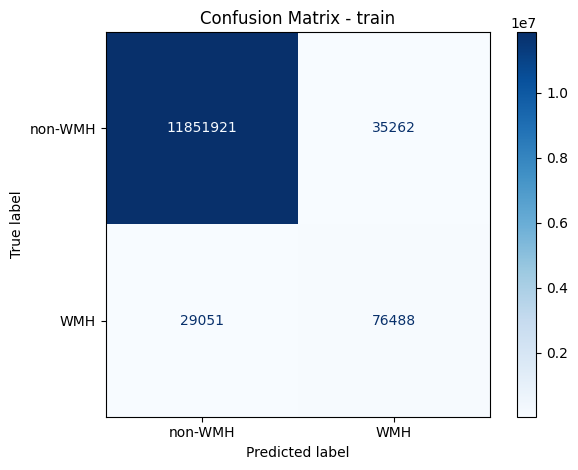

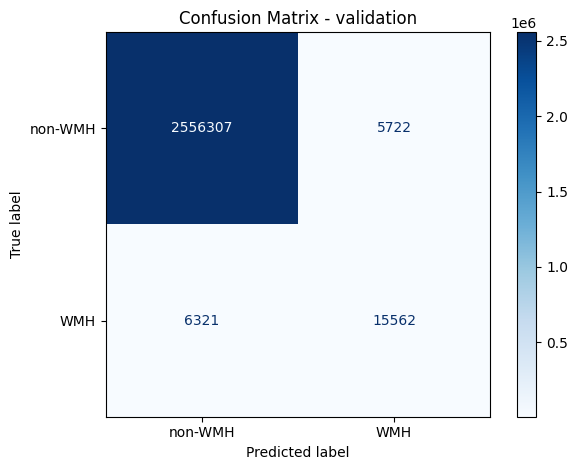

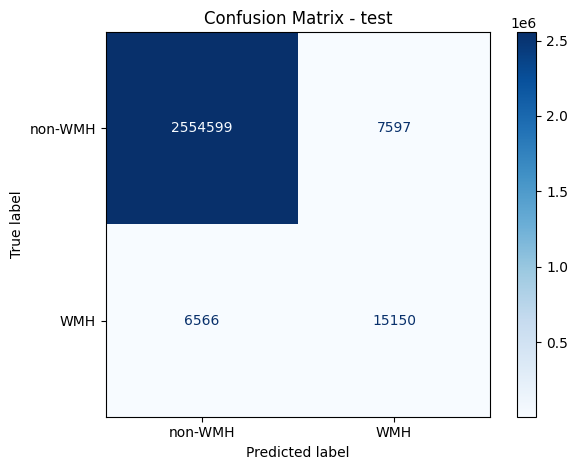

,set,threshold,accuracy,precision,recall,specificity,f1,dice
0,train,0.98,0.994637,0.684456,0.724737,0.997034,0.704021,0.704021
1,validation,0.98,0.995339,0.731160,0.711146,0.997767,0.721014,0.721014
2,test,0.98,0.994519,0.666022,0.697642,0.997035,0.681465,0.681465


In [15]:
results = []
sets = {"train": train_df, "validation": val_df, "test": test_df}

for name, set_df in sets.items():
    y_true = set_df["wmh"].to_numpy()
    y_pred = predict(model, set_df, best_threshold)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    results.append(
        {
            "set": name,
            "threshold": best_threshold,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "specificity": specificity_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "dice": dice_score(y_true, y_pred),
        }
    )

    ConfusionMatrixDisplay(cm, display_labels=["non-WMH", "WMH"]).plot(
        values_format="d",
        cmap="Blues",
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.savefig(output_dir / f"confusion_matrix_{name}.png", dpi=150)
    plt.show()

results_df = pd.DataFrame(results)
results_df.to_csv(output_dir / "metrics.csv", index=False)
results_df